# NLP Lab 2 — Stemming and String Distance

# 1. Стемінг в NLTK

 Стемінг — це процес скорочення слів до їхньої базової або кореневої форми.
 В NLTK існують різні алгоритми стемінгу, такі як Porter, Snowball і Lancaster.

In [6]:
import nltk
from nltk.stem import PorterStemmer
from nltk.stem.snowball import SnowballStemmer
from nltk.stem.lancaster import LancasterStemmer

In [7]:
porter = PorterStemmer()
snowball = SnowballStemmer("english")
lancaster = LancasterStemmer()

In [8]:
words = ["running","jumps","happily","programming","cared","fairly","sportingly"]

In [9]:
print("=== Porter ===")
print([porter.stem(w) for w in words])

print("=== Snowball ===")
print([snowball.stem(w) for w in words])

print("=== Lancaster ===")
print([lancaster.stem(w) for w in words])

=== Porter ===
['run', 'jump', 'happili', 'program', 'care', 'fairli', 'sportingli']
=== Snowball ===
['run', 'jump', 'happili', 'program', 'care', 'fair', 'sport']
=== Lancaster ===
['run', 'jump', 'happy', 'program', 'car', 'fair', 'sport']


## 2. Task 0 — Розподіл частотності коренів

У цьому завданні ми порівнюємо розподіл частотності оригінальних слів і коренів за допомогою корпусу NLTK.

In [10]:
import nltk
from nltk.book import text1
from nltk.probability import FreqDist
from nltk.stem import PorterStemmer

*** Introductory Examples for the NLTK Book ***
Loading text1, ..., text9 and sent1, ..., sent9
Type the name of the text or sentence to view it.
Type: 'texts()' or 'sents()' to list the materials.
text1: Moby Dick by Herman Melville 1851
text2: Sense and Sensibility by Jane Austen 1811
text3: The Book of Genesis
text4: Inaugural Address Corpus
text5: Chat Corpus
text6: Monty Python and the Holy Grail
text7: Wall Street Journal
text8: Personals Corpus
text9: The Man Who Was Thursday by G . K . Chesterton 1908


In [11]:
tokens = [w.lower() for w in text1 if w.isalpha()]

In [12]:
freq_original = FreqDist(tokens)

print(freq_original.most_common(20))

[('the', 14431), ('of', 6609), ('and', 6430), ('a', 4736), ('to', 4625), ('in', 4172), ('that', 3085), ('his', 2530), ('it', 2522), ('i', 2127), ('he', 1896), ('but', 1818), ('s', 1802), ('as', 1741), ('is', 1725), ('with', 1722), ('was', 1644), ('for', 1617), ('all', 1526), ('this', 1394)]


In [13]:
stemmer = PorterStemmer()

stem_tokens = [stemmer.stem(w) for w in tokens]

freq_stem = FreqDist(stem_tokens)

print(freq_stem.most_common(20))

[('the', 14431), ('of', 6613), ('and', 6437), ('a', 4736), ('to', 4628), ('in', 4172), ('that', 3085), ('it', 2898), ('hi', 2530), ('i', 2127), ('he', 1896), ('but', 1818), ('s', 1802), ('as', 1741), ('is', 1725), ('with', 1722), ('wa', 1645), ('whale', 1626), ('for', 1617), ('all', 1526)]


<Axes: title={'center': 'Most common words (original)'}, xlabel='Samples', ylabel='Counts'>

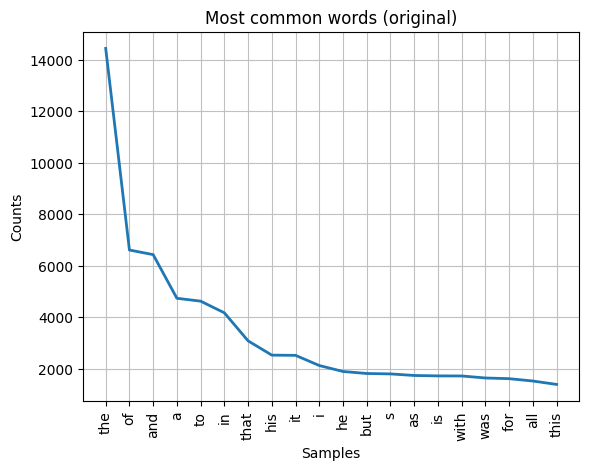

In [14]:
freq_original.plot(20, title="Most common words (original)")

<Axes: title={'center': 'Most common stems'}, xlabel='Samples', ylabel='Counts'>

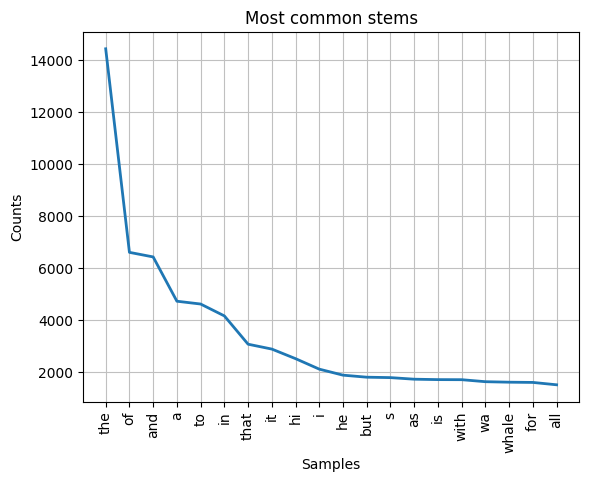

In [15]:
freq_stem.plot(20, title="Most common stems")

# 3. Task 1 — Український стемер із використанням регулярних виразів

У цьому завданні ми реалізуємо власний стемер для української мови із використанням регулярних виразів.

In [16]:
from nltk.stem import RegexpStemmer

In [17]:
class UkrainianStemmer(RegexpStemmer):
    
    def __init__(self):
        endings = r"(ами|ями|еві|ові|ого|ому|ими|ій|ий|а|е|у|ю|і|и|ти|ть|ли|ла|ло)$"
        super().__init__(endings, min=3)

In [18]:
ua = UkrainianStemmer()

test_words = [
    "машини",
    "машиною",
    "книгами",
    "гарний",
    "гарного",
    "бігти",
    "бігли"
]

for w in test_words:
    print(w, "->", ua.stem(w))

машини -> машин
машиною -> машино
книгами -> книг
гарний -> гарн
гарного -> гарн
бігти -> біг
бігли -> біг


In [28]:
from nltk.probability import FreqDist

sentence = "книга книги книгами книгою читати читаю читає читали"

tokens = sentence.split()

before = FreqDist(tokens)
print("Before stemming:")
print(before.most_common())

Before stemming:
[('книга', 1), ('книги', 1), ('книгами', 1), ('книгою', 1), ('читати', 1), ('читаю', 1), ('читає', 1), ('читали', 1)]


In [29]:
stemmed = [ua.stem(w) for w in tokens]
after = FreqDist(stemmed)
print("\nAfter stemming:")
print(after.most_common())


After stemming:
[('книг', 3), ('чита', 3), ('книго', 1), ('читає', 1)]


# 4. Task 2 — Алгоритм Вагнера-Фішера

Алгоритм Вагнера-Фішера обчислює відстань редагування між двома рядками за допомогою динамічного програмування.

In [30]:
def wagner_fischer_keyboard(a, b):
    m = len(a)
    n = len(b)

    matrix = [[0]*(n+1) for _ in range(m+1)]

    for i in range(m+1):
        matrix[i][0] = i

    for j in range(n+1):
        matrix[0][j] = j

    for i in range(1, m+1):
        for j in range(1, n+1):
            cost = keyboard_distance(a[i-1], b[j-1])  # вартість залежить від клавіатури
            matrix[i][j] = min(
                matrix[i-1][j] + 1,
                matrix[i][j-1] + 1,
                matrix[i-1][j-1] + cost
            )

    return matrix[m][n]

In [31]:
print("Keyboard WF:")
print(wagner_fischer_keyboard("form", "from"))   # транспозиція — клав. відстань
print(wagner_fischer_keyboard("test", "rest"))   # t→r: відстань на клавіатурі = 4

Keyboard WF:
2
1


# 5. Keyboard Distance (QWERTY)

We modify substitution cost based on keyboard proximity.

In [32]:
keyboard = {
'q':(0,0),'w':(0,1),'e':(0,2),'r':(0,3),'t':(0,4),'y':(0,5),'u':(0,6),'i':(0,7),'o':(0,8),'p':(0,9),
'a':(1,0),'s':(1,1),'d':(1,2),'f':(1,3),'g':(1,4),'h':(1,5),'j':(1,6),'k':(1,7),'l':(1,8),
'z':(2,0),'x':(2,1),'c':(2,2),'v':(2,3),'b':(2,4),'n':(2,5),'m':(2,6)
}

In [33]:
def keyboard_distance(a, b):
    if a == b:
        return 0
    if a in keyboard and b in keyboard:
        x1, y1 = keyboard[a]
        x2, y2 = keyboard[b]
        return abs(x1-x2) + abs(y1-y2)
    return 1

# 6. Відстань Дамерау-Левенштейна

Ця версія включає операцію транспозиції.

In [34]:
def damerau_levenshtein(a, b):
    m = len(a)
    n = len(b)

    d = [[0]*(n+1) for _ in range(m+1)]

    for i in range(m+1):
        d[i][0] = i

    for j in range(n+1):
        d[0][j] = j

    for i in range(1, m+1):
        for j in range(1, n+1):
            cost = 0 if a[i-1] == b[j-1] else 1  # стандартна вартість заміни

            d[i][j] = min(
                d[i-1][j] + 1,        # видалення
                d[i][j-1] + 1,        # вставка
                d[i-1][j-1] + cost    # заміна
            )

            # транспозиція (a[i-1] і a[i-2] поміняні місцями)
            if i > 1 and j > 1 and a[i-1] == b[j-2] and a[i-2] == b[j-1]:
                d[i][j] = min(d[i][j], d[i-2][j-2] + 1)

    return d[m][n]

In [35]:
print("\nDamerau-Levenshtein:")
print(damerau_levenshtein("form", "from"))  # 1 (транспозиція)
print(damerau_levenshtein("test", "rest"))  # 1 (заміна t→r, cost=1)


Damerau-Levenshtein:
1
1
